I052

Reya Oberoi

ATML_Exp5_WGAN

In [1]:
!pip install torch torchvision matplotlib tqdm

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

Load CIFAR dataset

In [3]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [00:09<00:00, 18.7MB/s]


In [11]:
print("Dataset size:", len(dataset))
print("Batch size:", loader.batch_size)

Dataset size: 50000
Batch size: 64


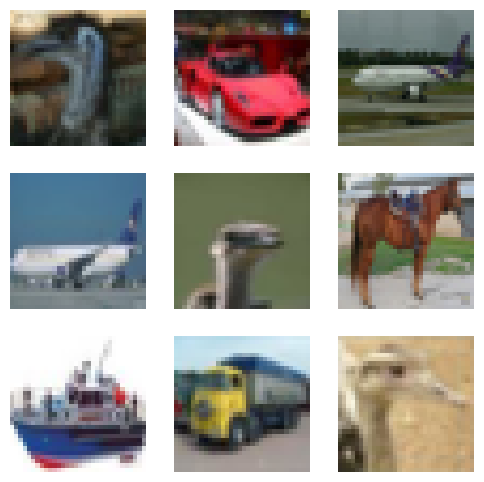

In [12]:
import numpy as np

dataiter = iter(loader)
images, labels = next(dataiter)

fig = plt.figure(figsize=(6,6))

for i in range(9):
    ax = fig.add_subplot(3,3,i+1)
    img = images[i] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.axis("off")

Define Generator

In [4]:
class Generator(nn.Module):

    def __init__(self, z_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, 3*32*32),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.net(x)
        return x.view(-1,3,32,32)

Define Critic (Discriminator in WGAN)

In [5]:
class Critic(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*32*32,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1)
        )

    def forward(self,x):
        return self.net(x)

In [13]:
print(G)
print(C)

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=3072, bias=True)
    (7): Tanh()
  )
)
Critic(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Linear(in_features=256, out_features=1, bias=True)
  )
)


Initialize models

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
C = Critic().to(device)

Hyperparameters

In [7]:
z_dim = 100
lr = 0.00005
batch_size = 64
n_critic = 5
clip_value = 0.01
epochs = 50

Optimizers

In [8]:
opt_G = torch.optim.RMSprop(G.parameters(), lr=lr)
opt_C = torch.optim.RMSprop(C.parameters(), lr=lr)

Number of Parameters

In [14]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Generator parameters:", count_params(G))
print("Critic parameters:", count_params(C))

Generator parameters: 3831552
Critic parameters: 1704961


Training loop

In [9]:
for epoch in range(epochs):

    for real,_ in tqdm(loader):

        real = real.to(device)
        batch = real.size(0)

        for _ in range(n_critic):

            noise = torch.randn(batch, z_dim).to(device)
            fake = G(noise)

            loss_C = -(torch.mean(C(real)) - torch.mean(C(fake)))

            opt_C.zero_grad()
            loss_C.backward()
            opt_C.step()

            for p in C.parameters():
                p.data.clamp_(-clip_value, clip_value)

        noise = torch.randn(batch, z_dim).to(device)
        fake = G(noise)

        loss_G = -torch.mean(C(fake))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print("Epoch:",epoch,"Loss G:",loss_G.item(),"Loss C:",loss_C.item())

100%|██████████| 782/782 [00:30<00:00, 25.59it/s]


Epoch: 0 Loss G: -0.1253112256526947 Loss C: -1.53653883934021


100%|██████████| 782/782 [00:26<00:00, 29.28it/s]


Epoch: 1 Loss G: -0.28861701488494873 Loss C: -9.64748477935791


100%|██████████| 782/782 [00:27<00:00, 28.94it/s]


...

Epoch: 47 Loss G: -0.012380488216876984 Loss C: -4.031368732452393


100%|██████████| 782/782 [00:28<00:00, 27.77it/s]


Epoch: 48 Loss G: 0.03737226128578186 Loss C: -1.2484854459762573


100%|██████████| 782/782 [00:27<00:00, 28.67it/s]

Epoch: 49 Loss G: -0.06167022883892059 Loss C: -0.304762601852417


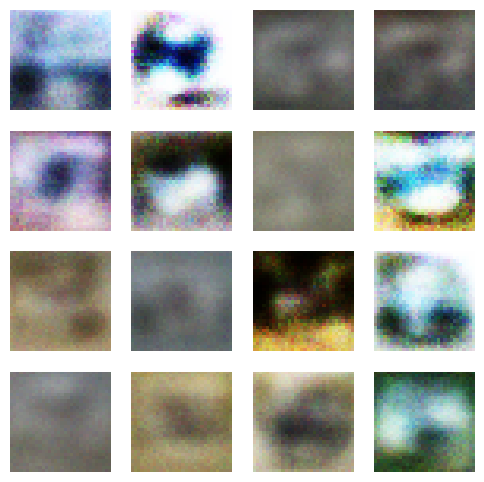

In [16]:
noise = torch.randn(16,100).to(device)

with torch.no_grad():
    fake = G(noise).cpu()

fig = plt.figure(figsize=(6,6))

for i in range(16):
    ax = fig.add_subplot(4,4,i+1)
    img = fake[i] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.axis("off")

In [10]:
torch.save(G.state_dict(),"generator.pth")

Trained a WGAN on the CIFAR-10 dataset using a generator and a critic network. During training, the critic learned to distinguish real images from generated ones while the generator improved its ability to create realistic images from random noise. The results show that the model successfully learns the data distribution and can generate synthetic images similar to CIFAR-10 samples.